# Breast Cancer Wisconsin — Exploratory Data Analysis
**Dataset:** sklearn Breast Cancer Wisconsin  
**Goal:** Explore feature distributions and identify the strongest predictors of malignancy.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Loading and building DataFrame
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = data.target
df['diagnosis'] = 1 - df['diagnosis']                              # invert labels: 0 = Benign, 1 = Malignant
df['diagnosis_label'] = df['diagnosis'].map({0: 'Benign', 1: 'Malignant'})  # Add a new column with string labels

print(df.shape)
print(df['diagnosis_label'].value_counts())
df.head()

(569, 32)
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,Malignant


In [15]:
# Display all columns in the DataFrame
pd.set_option('display.max_columns', None)

In [16]:
# Summary statistics
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.372583
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,0.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [17]:
print(df['diagnosis_label'].value_counts())
print(f"\nBenign: {357/569*100:.1f}%")
print(f"Malignant: {212/569*100:.1f}%")

diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64

Benign: 62.7%
Malignant: 37.3%


## Phase 1: Data Overview
The dataset contains 569 samples with 30 features and no missing values, making it clean and ready for analysis.
The features are structured in 10 measurements represented by mean, standard error, and worst values.
The class distribution is relatively balanced, with 63% benign and 37% malignant cases, which helps reduce bias in model predictions.
However, features vary significantly in scale (e.g., radius ~14,area ~654), suggesting that feature scaling is important for the accuracy of machine learning models.
Overall, the dataset appears well-structured for building and evaluating classification models. 

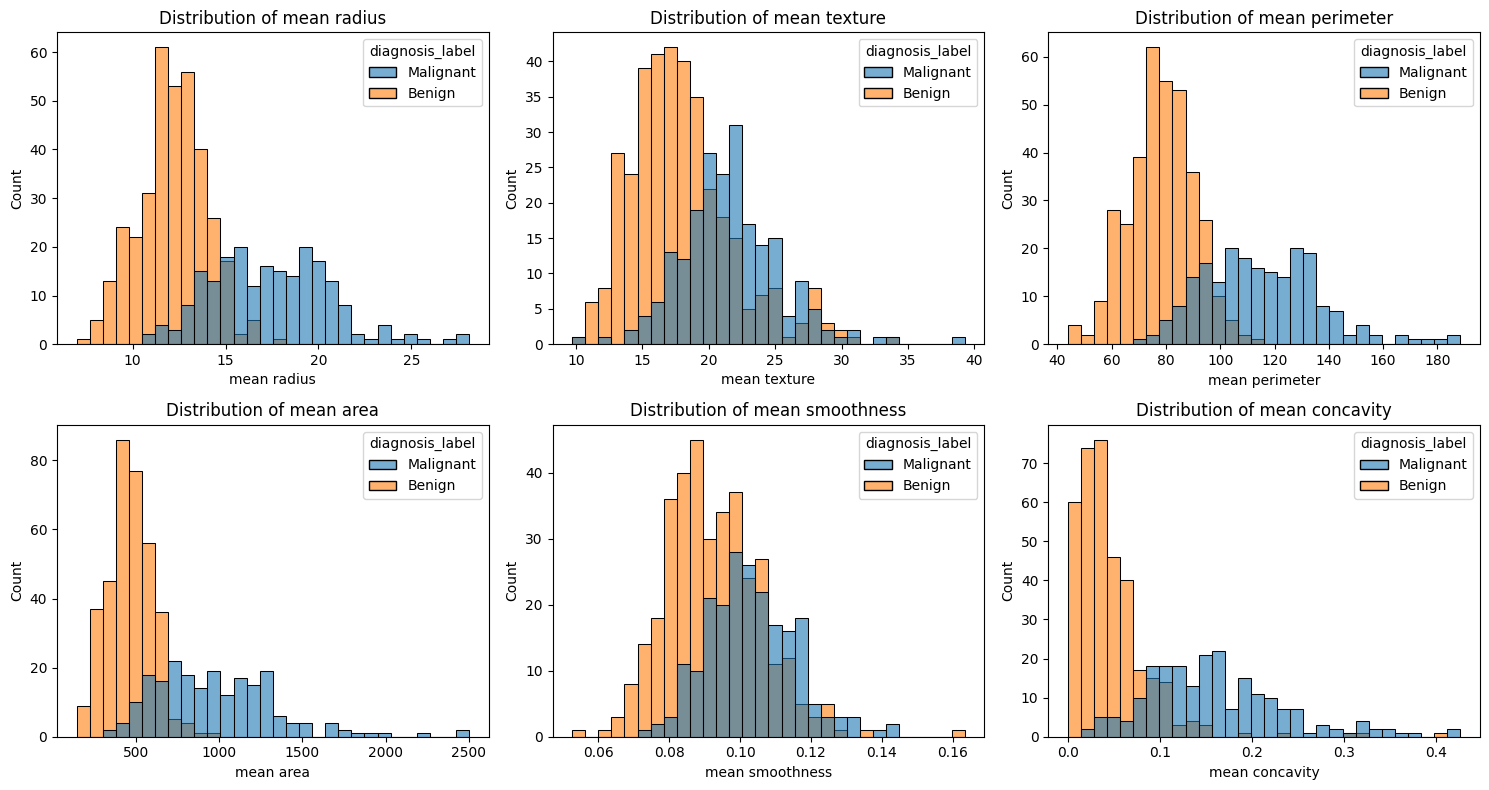

In [18]:
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 
                    'mean area', 'mean smoothness', 'mean concavity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.histplot(data=df, x=feature, hue='diagnosis_label',
                 bins=30, alpha=0.6, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../images/histograms.png', dpi=150, bbox_inches='tight')
plt.show()

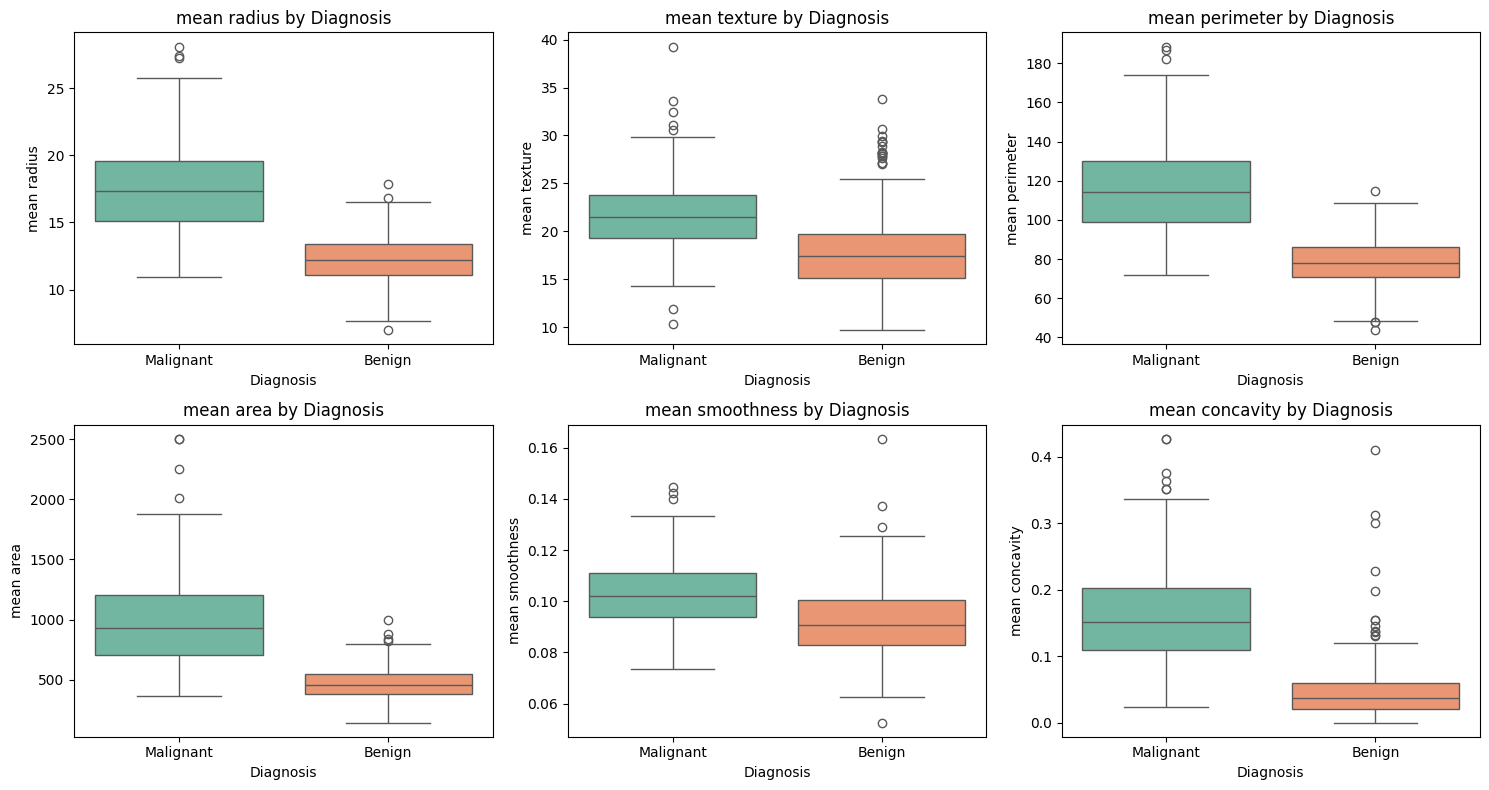

In [19]:
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 
                    'mean area', 'mean smoothness', 'mean concavity']

fig,axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, feature in enumerate(features_to_plot):
    sns.boxplot(data=df, x='diagnosis_label', y=feature, 
                hue='diagnosis_label', palette='Set2', legend=False, ax=axes[i])
    axes[i].set_title(f'{feature} by Diagnosis')
    axes[i].set_xlabel('Diagnosis')
    axes[i].set_ylabel(feature) 
plt.tight_layout()
plt.savefig('../images/boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
dl_group = df.groupby('diagnosis_label').mean().round(2)
dl_group[['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean concavity']]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean concavity
diagnosis_label,,,,,,
Benign,12.15,17.91,78.08,462.79,0.09,0.05
Malignant,17.46,21.60,115.37,978.38,0.10,0.16


## Phase 2: Univariate Analysis

Feature analysis revealed that multiple variables contribute to class separation, with mean area turning out to be one of the main differentiator between malignant and benign cases. 
Boxplot visualization showed that generally, malignant cases have a higher spread meaning a larger variability across multiple features especially those related to size, indicating how different the characteristics are. In contrast, benign cases showed a more compact spread, although they present a higher number of outliers in certain features. 
Moreover, the grouped table comparison confirms that malignant cases show more consistent large values across size-related features (e.g., area), reinforcing their distinction from benign tumors in the dataset.

In [21]:
# Correlation matrix with numeric columns only
corr_matrix = df.corr(numeric_only=True)

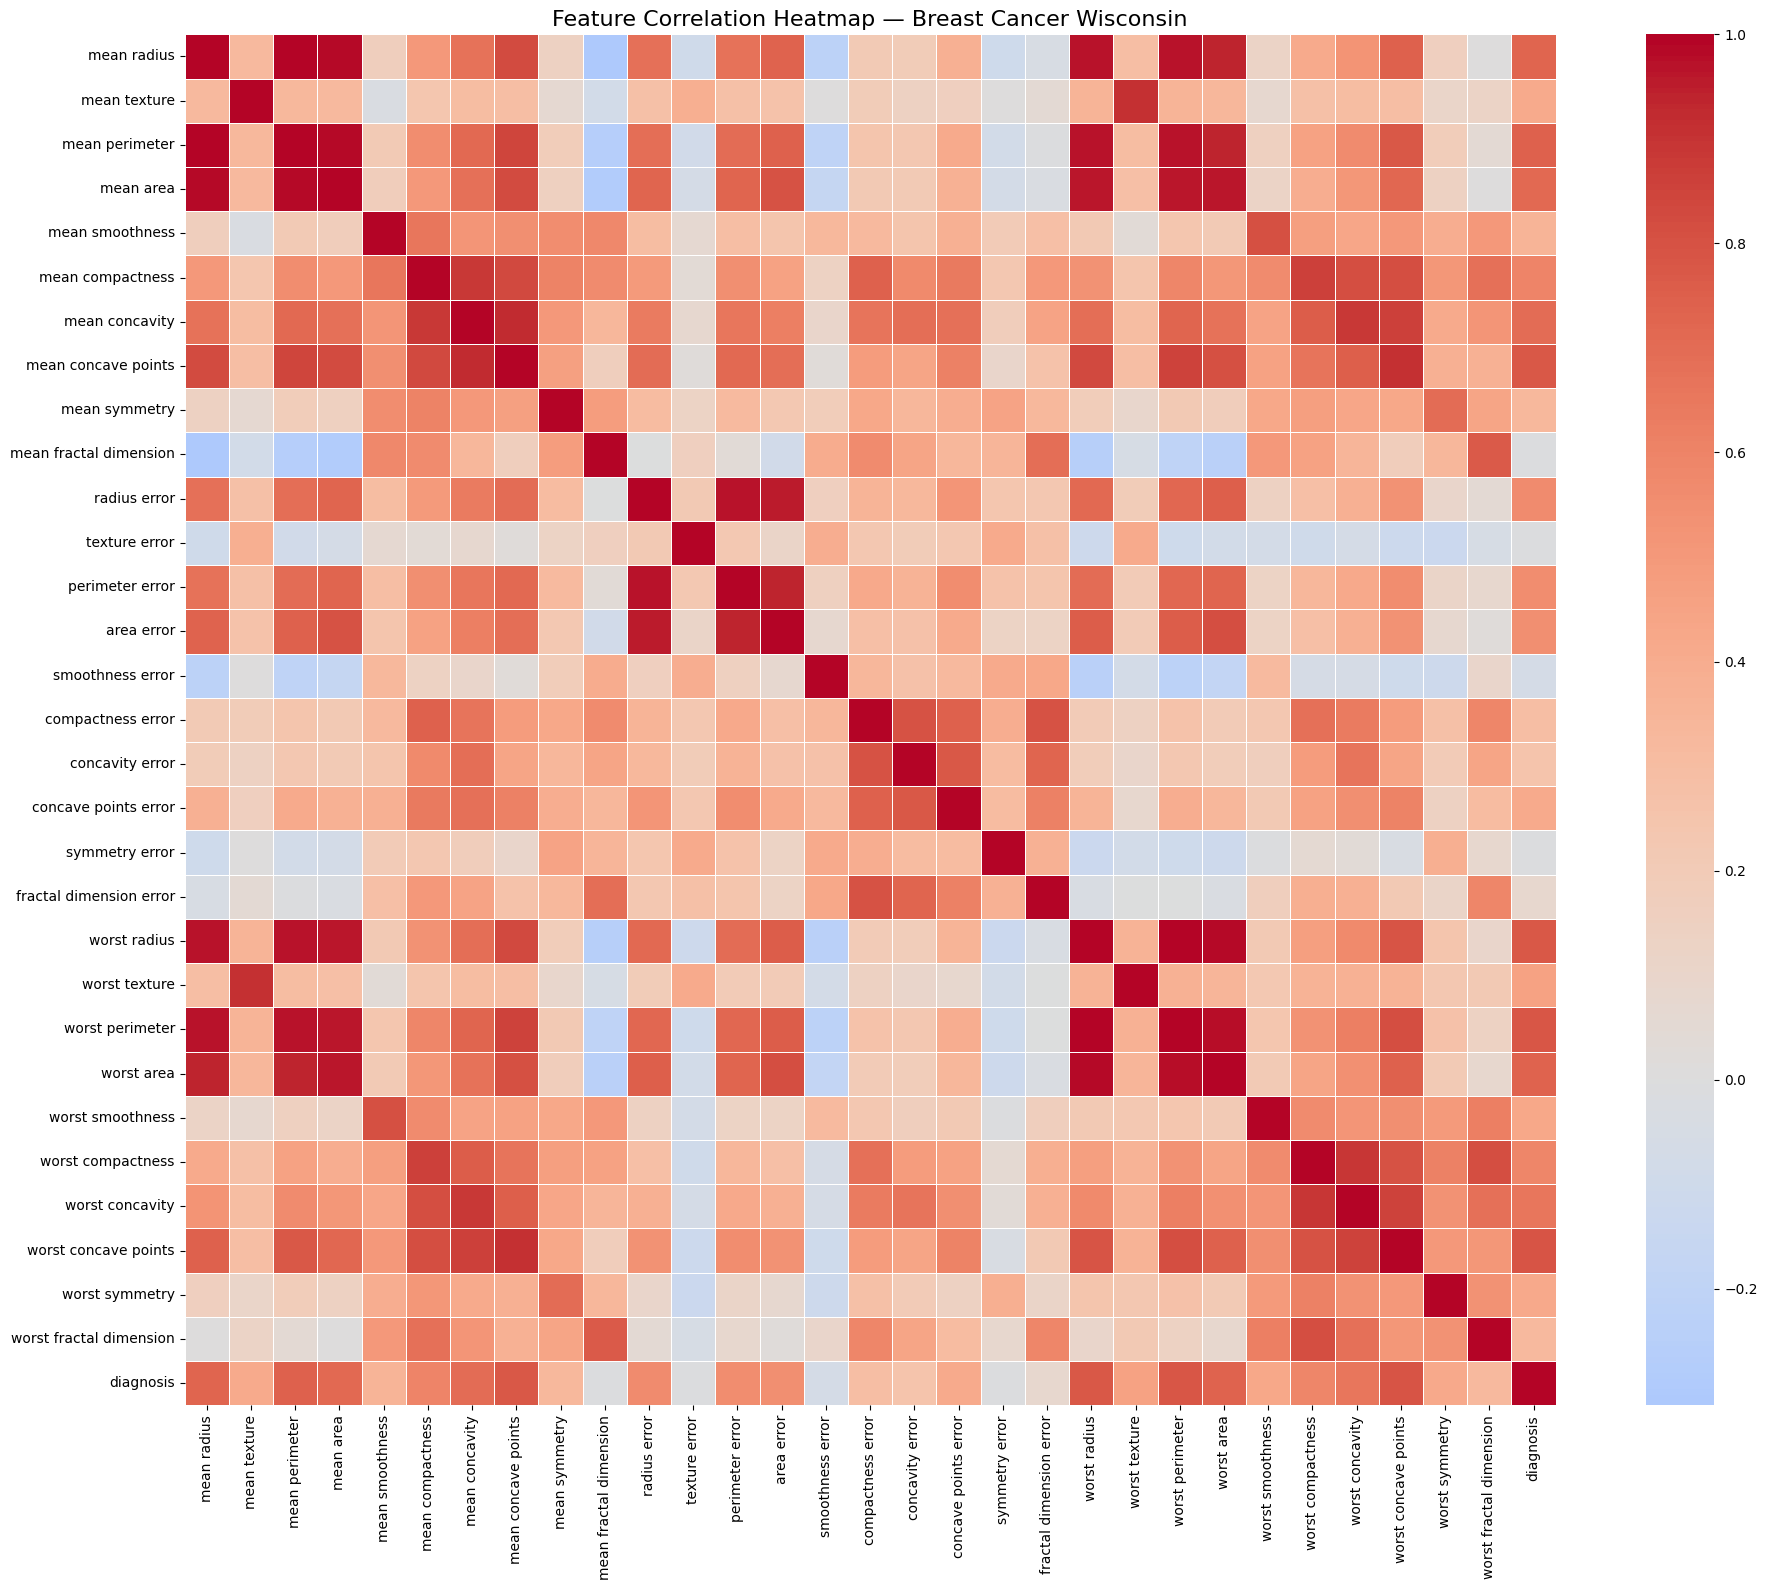

In [22]:
plt.figure(figsize=(20, 16))

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)

plt.title('Feature Correlation Heatmap — Breast Cancer Wisconsin', fontsize=16)
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
tc_sorted = corr_matrix['diagnosis'].sort_values(ascending=False)
tc_sorted = tc_sorted.drop('diagnosis')  # Remove self-correlation
tc_sorted.head(10)

worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
Name: diagnosis, dtype: float64

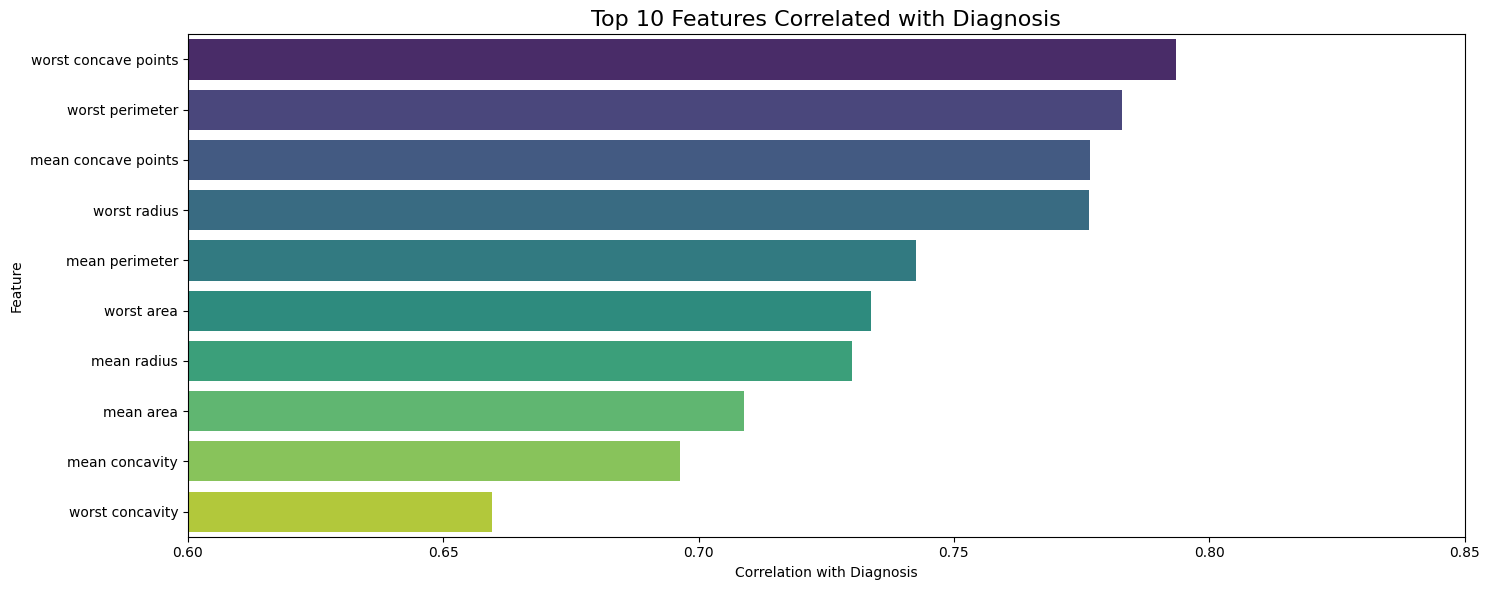

In [24]:
tc_sorted_head = tc_sorted.head(10)

plt.figure(figsize=(15, 6))
sns.barplot(
    x=tc_sorted_head.values, 
    y=tc_sorted_head.index, 
    hue=tc_sorted_head.index, 
    palette='viridis', 
    legend=False
)

plt.title('Top 10 Features Correlated with Diagnosis', fontsize=16)
plt.xlabel('Correlation with Diagnosis')
plt.ylabel('Feature')
plt.xlim(0.6, 0.85)
plt.tight_layout()
plt.savefig('../images/top_correlated_features.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 3: Correlation Analysis

Looking at the above heatmap and the top 10 correlation values, we can clearly see that the diagnosis is correlated with size-related properties. As the size increases, these features are more likely to be associated with malignant cases. However, correlation does not tell the full story here due to the presence of confounding effects. Certain features, such as radius and area, are highly correlated. Some features capture the same underlying information. Therefore, we do not have 10 independent features.

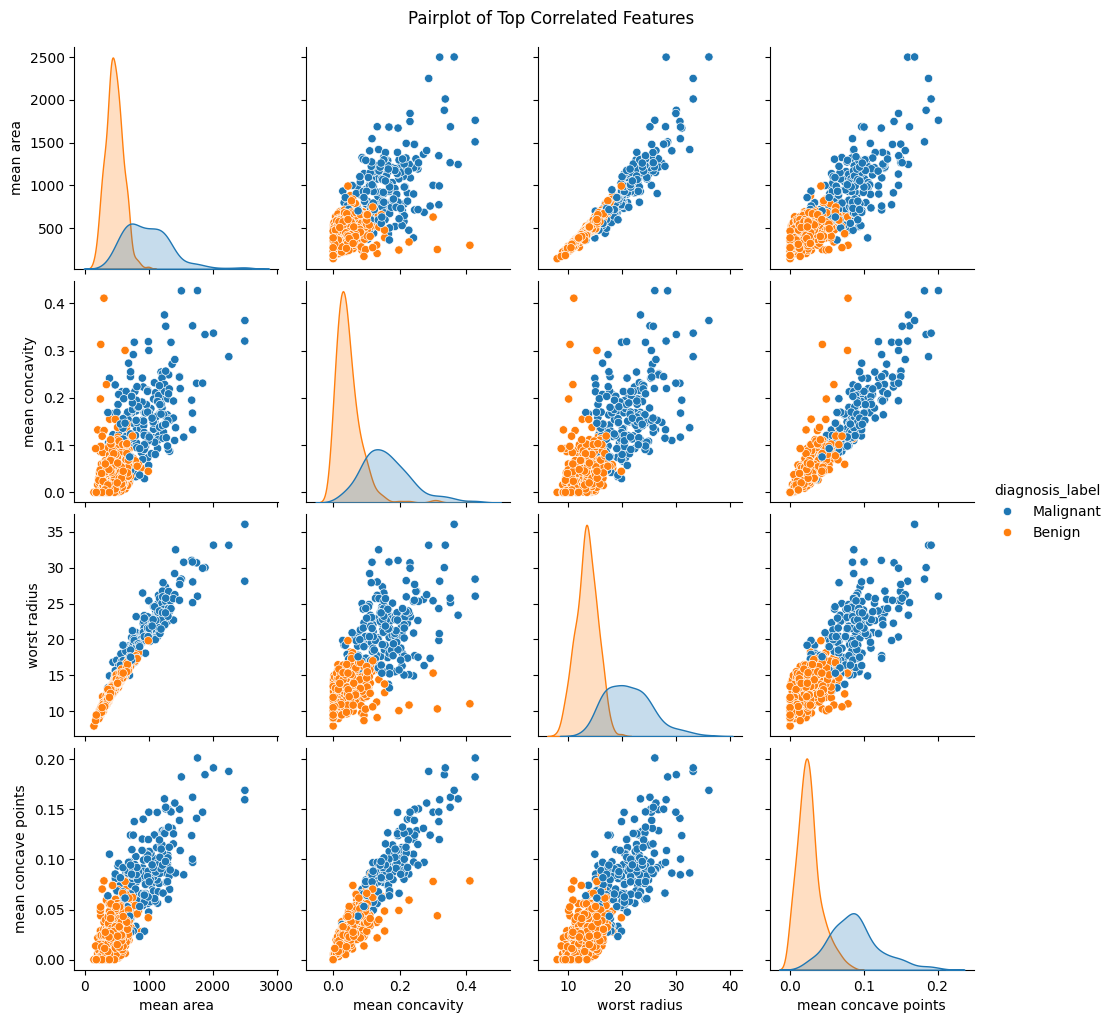

In [25]:
features_to_plot = ['mean area', 'mean concavity', 'worst radius', 'mean concave points', 'diagnosis_label']

sns.pairplot(df[features_to_plot], hue='diagnosis_label')
plt.suptitle('Pairplot of Top Correlated Features', y=1.02)
plt.savefig('../images/pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 4: Bivariate Analysis

The pairplot figure above shows the scatter plots for the correlated features. From this, we can observe that malignant cases tend to be larger compared to benign cases.

## Phase 5: Summary of the key findings from the entire Breast-Cancer-Wisconsin-EDA

- A dataset of 569 samples with 30 features was used to compare benign and malignant cases.
- The class distribution shows a ratio of 63% benign to 37% malignant cases.
- Malignant cases displayed higher variability compared to benign cases, and were consistently larger in size.
- Size-related features were the strongest indicators of malignancy, effectively differentiating the two groups.
- Shape irregularity features (concavity, concave points) complemented size features, together providing the strongest separation between malignant and benign cases.